# Day 3 – Univariate & Bivariate EDA on Netflix Dataset

## Objective

The objective of this analysis is to explore the Netflix dataset using univariate and bivariate exploratory data analysis techniques to identify trends, distributions, and relationships between variables.

##  Import Required Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

##  Load Cleaned Dataset

In [7]:
import pandas as pd

df = pd.read_csv(r"C:\Users\FAESA C F\OneDrive\Desktop\EDA project\data\interim\cleaned_day2.csv")



#  Univariate Analysis

###  Content Type Distribution

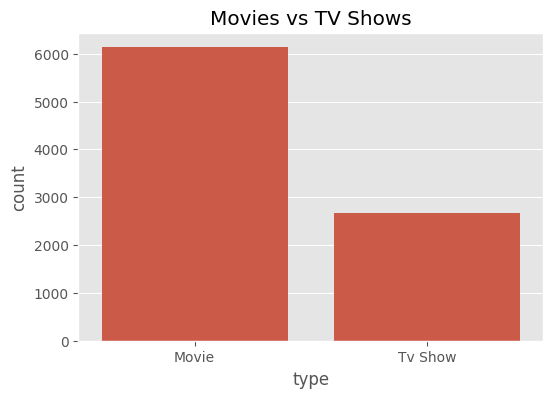

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="type", data=df)

plt.title("Movies vs TV Shows")
plt.savefig("../reports/figures/type_count.png")
plt.show()

### Insight:
Movies are more common than TV Shows in the Netflix dataset.

###  Rating Distribution

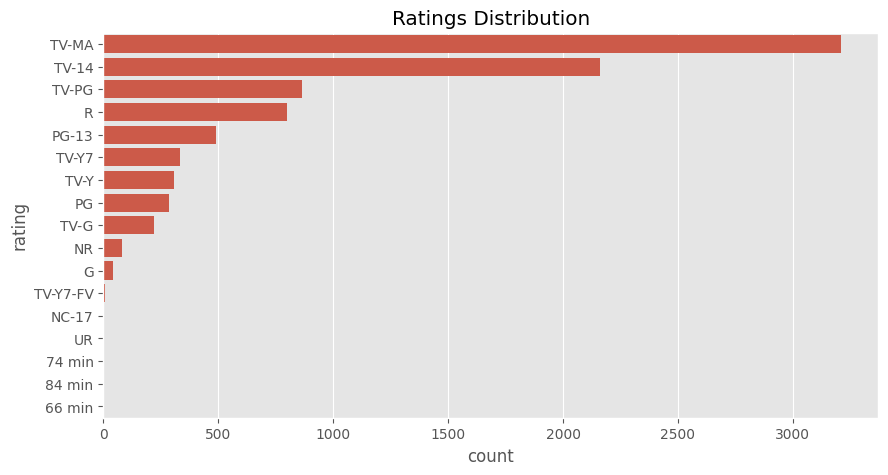

In [10]:
plt.figure(figsize=(10,5))

sns.countplot(y="rating", data=df,
              order=df["rating"].value_counts().index)

plt.title("Ratings Distribution")
plt.savefig("../reports/figures/rating_distribution.png")
plt.show()

### Insight:
TV-MA and TV-14 are the most frequent ratings on Netflix.

###  Top Countries


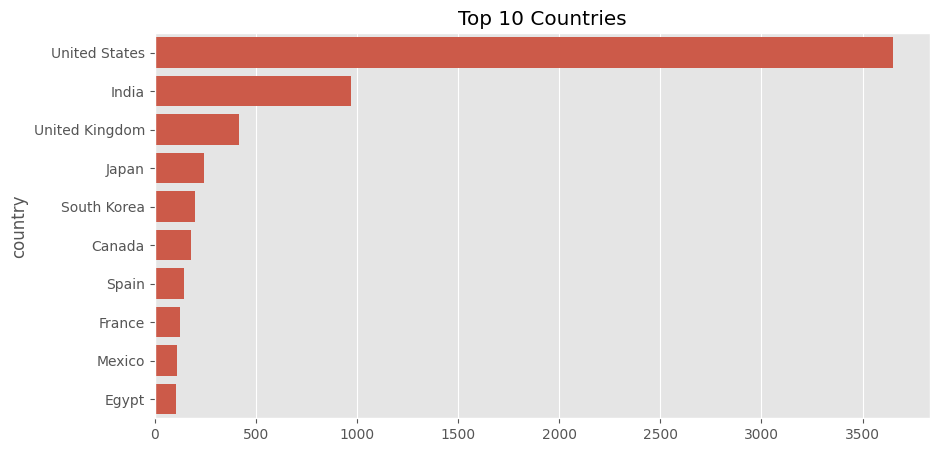

In [11]:
top_country = df["country"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_country.values,
            y=top_country.index)

plt.title("Top 10 Countries")
plt.savefig("../reports/figures/top_countries.png")
plt.show()

### Insight:
USA contributes the highest amount of Netflix content.

###  Release Year Distribution

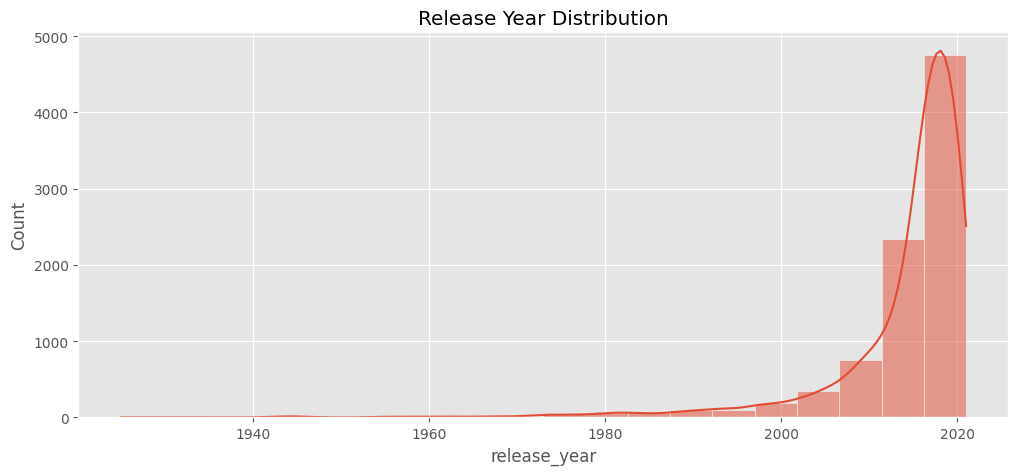

In [12]:
plt.figure(figsize=(12,5))

sns.histplot(df["release_year"], bins=20, kde=True)

plt.title("Release Year Distribution")
plt.savefig("../reports/figures/release_year.png")
plt.show()

### Insight:
Netflix content production increased rapidly after 2015.

###  Movie Duration Distribution

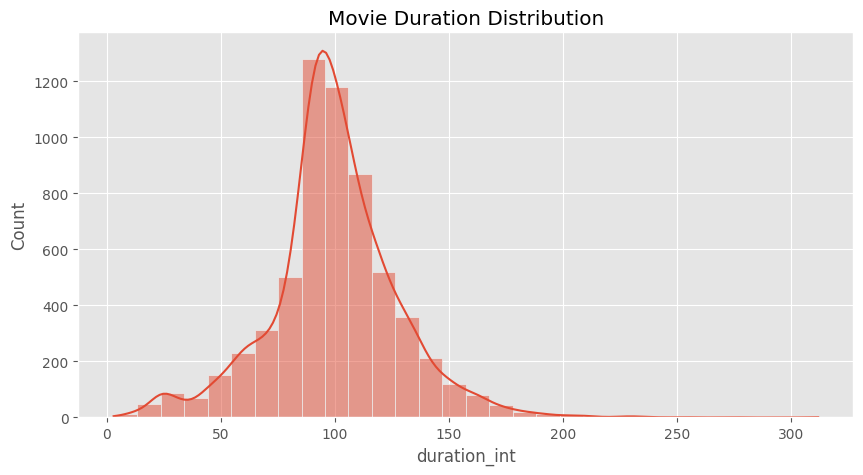

In [13]:
movie_df = df[df["type"] == "Movie"].copy()

movie_df["duration_int"] = (
    movie_df["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

movie_df.dropna(subset=["duration_int"], inplace=True)

movie_df["duration_int"] = movie_df["duration_int"].astype(int)

plt.figure(figsize=(10,5))

sns.histplot(movie_df["duration_int"], bins=30, kde=True)

plt.title("Movie Duration Distribution")

plt.savefig("../reports/figures/movie_duration.png")

plt.show()

### Insight:
Most movies have durations between 80 and 120 minutes.

#   Bivariate Analysis

(Bivariate = relationship between TWO columns)

###  Type vs Rating

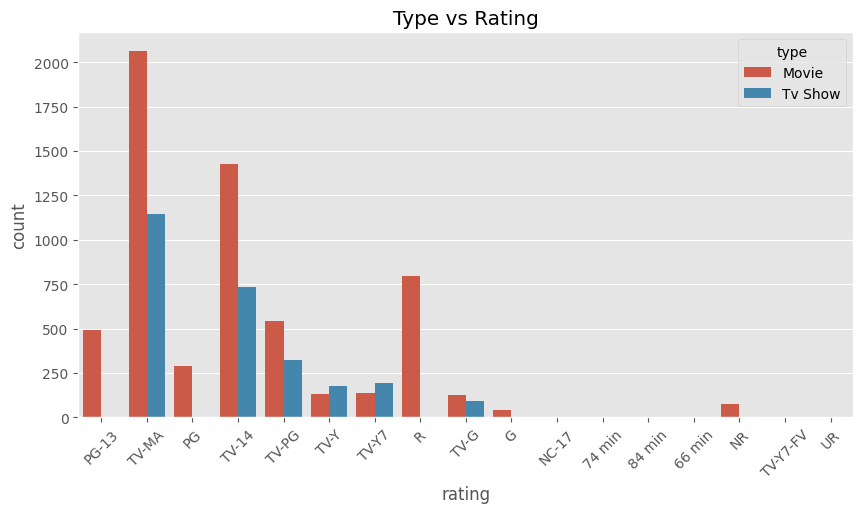

In [14]:
plt.figure(figsize=(10,5))

sns.countplot(x="rating",
              hue="type",
              data=df)

plt.xticks(rotation=45)

plt.title("Type vs Rating")
plt.savefig("../reports/figures/type_vs_rating.png")
plt.show()

### Insight:
TV Shows mostly fall under TV rating categories.

###  Release Year vs Type

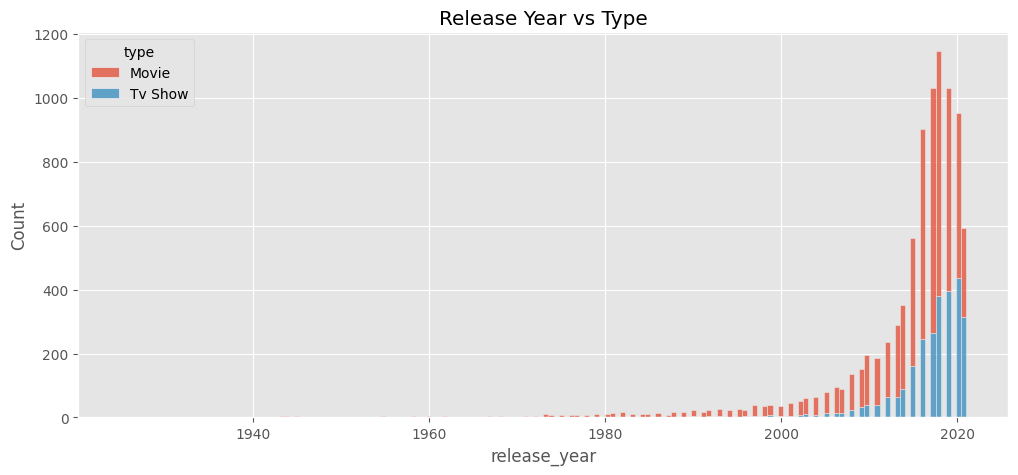

In [15]:
plt.figure(figsize=(12,5))

sns.histplot(data=df,
             x="release_year",
             hue="type",
             multiple="stack")

plt.title("Release Year vs Type")
plt.savefig("../reports/figures/release_year_vs_type.png")
plt.show()

### Insight
Movies dominate older releases.

###  Country vs Content Type

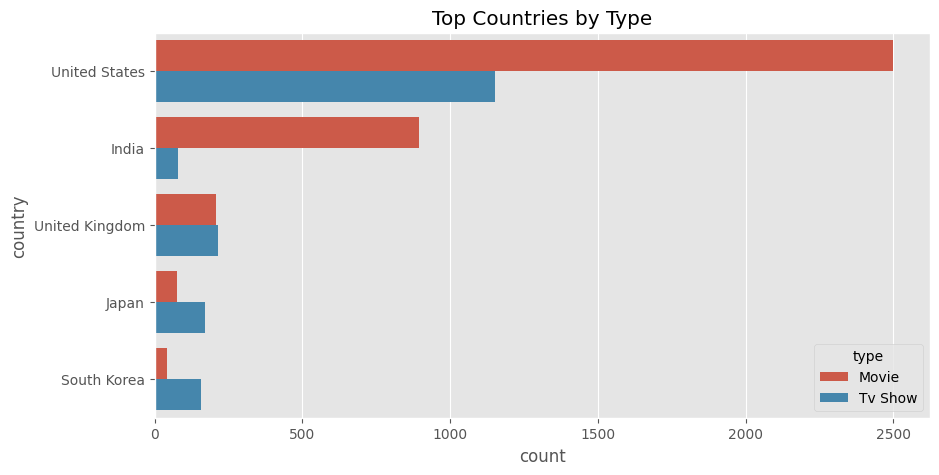

In [18]:
top = df[df["country"].isin(df["country"].value_counts().head(5).index)]

plt.figure(figsize=(10,5))

sns.countplot(y="country",
              hue="type",
              data=top)

plt.title("Top Countries by Type")
plt.savefig("../reports/figures/country_vs_type.png")
plt.show()

### Insight
USA produces more movies than TV Shows.

###  Correlation Heatmap

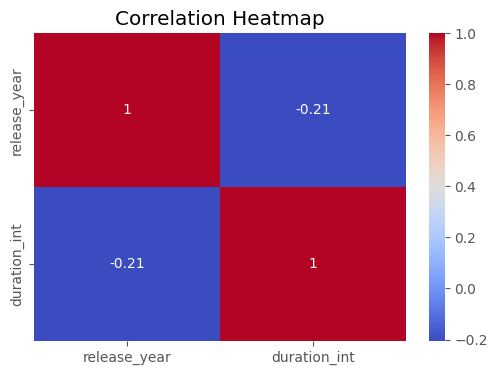

In [19]:
numeric_df = movie_df[["release_year", "duration_int"]]

plt.figure(figsize=(6,4))

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.savefig("../reports/figures/heatmap.png")
plt.show()

###  Insight:
The correlation heatmap shows the relationship between numerical features in the dataset. 
There is no strong correlation between release year and movie duration, indicating that movie length does not significantly depend on release year.

# Key Insights:

1. Movies are more common than TV Shows.
2. TV-MA is the most common rating.
3. USA contributes the highest amount of content.
4. Netflix content increased significantly after 2015.
5. Most movie durations range from 80–120 minutes.

#  Conclusion

This analysis helped understand Netflix content trends, ratings distribution, country contributions, and relationships between important features using visual exploratory data analysis.